# Actividad 15 Perceptrón

¿Qué es el perceptrón?
En 1957 Frank Rosenblatt inventó el perceptrón en el laboratorio aeronáutico de Cornell. Basándose en los primeros conceptos de neuronas artificiales, propuso la “regla de aprendizaje del perceptrón”.

Un perceptrón es una neurona artificial, y, por tanto, una unidad de red neuronal. El perceptrón efectúa cálculos para detectar características o tendencias en los datos de entrada. Se trata de un algoritmo para el aprendizaje supervisado de clasificadores binarios. Ese algoritmo es el que permite que las neuronas artificiales aprendan y traten los elementos de una serie de datos. El perceptrón desempeña un papel esencial en los proyectos de Machine Learning. Se utiliza en gran medida para clasificar datos, o como algoritmo que permite simplificar o supervisar las capacidades de aprendizaje de los clasificadores binarios.

Recordemos que el aprendizaje supervisado consiste en enseñar a un algoritmo a hacer predicciones. Para conseguirlo, se alimenta el algoritmo con ayuda de datos que ya están etiquetados correctamente.

El perceptrón se utiliza principalmente para clasificar información en diferentes categorías a partir de datos de entrada. Sus aplicaciones incluyen la detección de correo spam, el reconocimiento de patrones, la evaluación de riesgos financieros, el diagnóstico médico y el control de calidad en procesos industriales. Además, sus principios son la base de las redes neuronales artificiales


## Datos linealmente separables

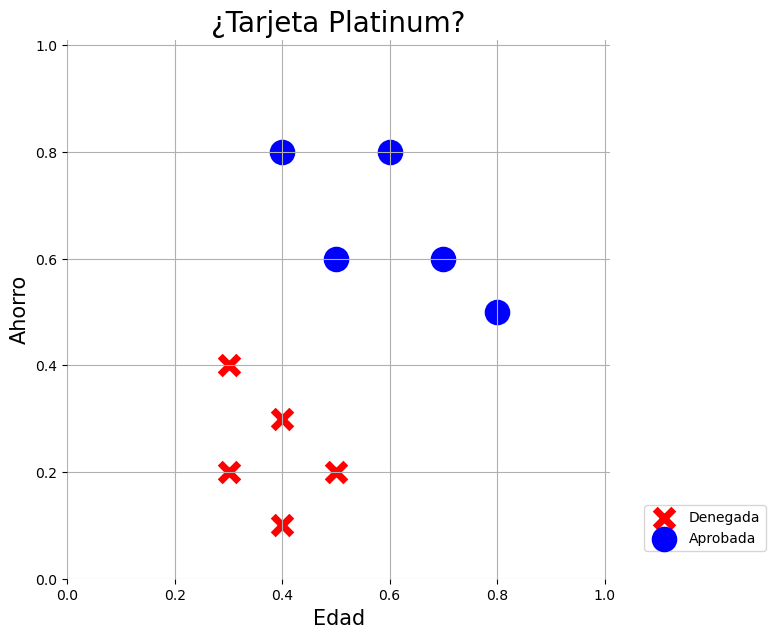

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de 10 personas -> [edad, ahorro]
personas = np.array([
    [0.3, 0.4], [0.4, 0.3],
    [0.3, 0.2], [0.4, 0.1],
    [0.5, 0.2], [0.4, 0.8],
    [0.6, 0.8], [0.5, 0.6],
    [0.7, 0.6], [0.8, 0.5]
])

# 1: aprobada   0: denegada
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Gráfica de dispersión (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(
    personas[clases == 0].T[0],
    personas[clases == 0].T[1],
    marker="x",
    s=180,
    color="red",
    linewidths=5,
    label="Denegada"
)

plt.scatter(
    personas[clases == 1].T[0],
    personas[clases == 1].T[1],
    marker="o",
    s=180,
    color="blue",
    linewidths=5,
    label="Aprobada"
)

plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)

plt.xlim((0, 1.01))
plt.ylim((0, 1.01))

plt.grid()
plt.show()

## Funcion de activacion

In [5]:
# w1*x1 + w2*x2 + ... + wn*xn

def activacion(pesos, x, b):
    z = pesos * x
    
    if z.sum() + b > 0:
        return 1
    else:
        return 0

pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

pesos, b, activacion(pesos, [0.5, 0.5], b)

(array([-0.14547414,  0.03230582]), 0.3117636942778166, 1)

## Entrenamiento del Perceptron 

In [9]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)

tasa_de_aprendizaje = 0.01
epocas = 100

for epoca in range(epocas):
    
    error_total = 0
    
    for i in range(len(personas)):
        
        prediccion = activacion(pesos, personas[i], b)
        
        error = clases[i] - prediccion
        
        error_total += error**2
        
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        
        b += tasa_de_aprendizaje * error
        
    print(error_total, end=" ")

activacion(pesos, [0.5, 0.8], b)

5 5 5 5 5 4 2 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

1

# Zonas de aprobacion

## Grafica de dispersion[edad, ahorro]

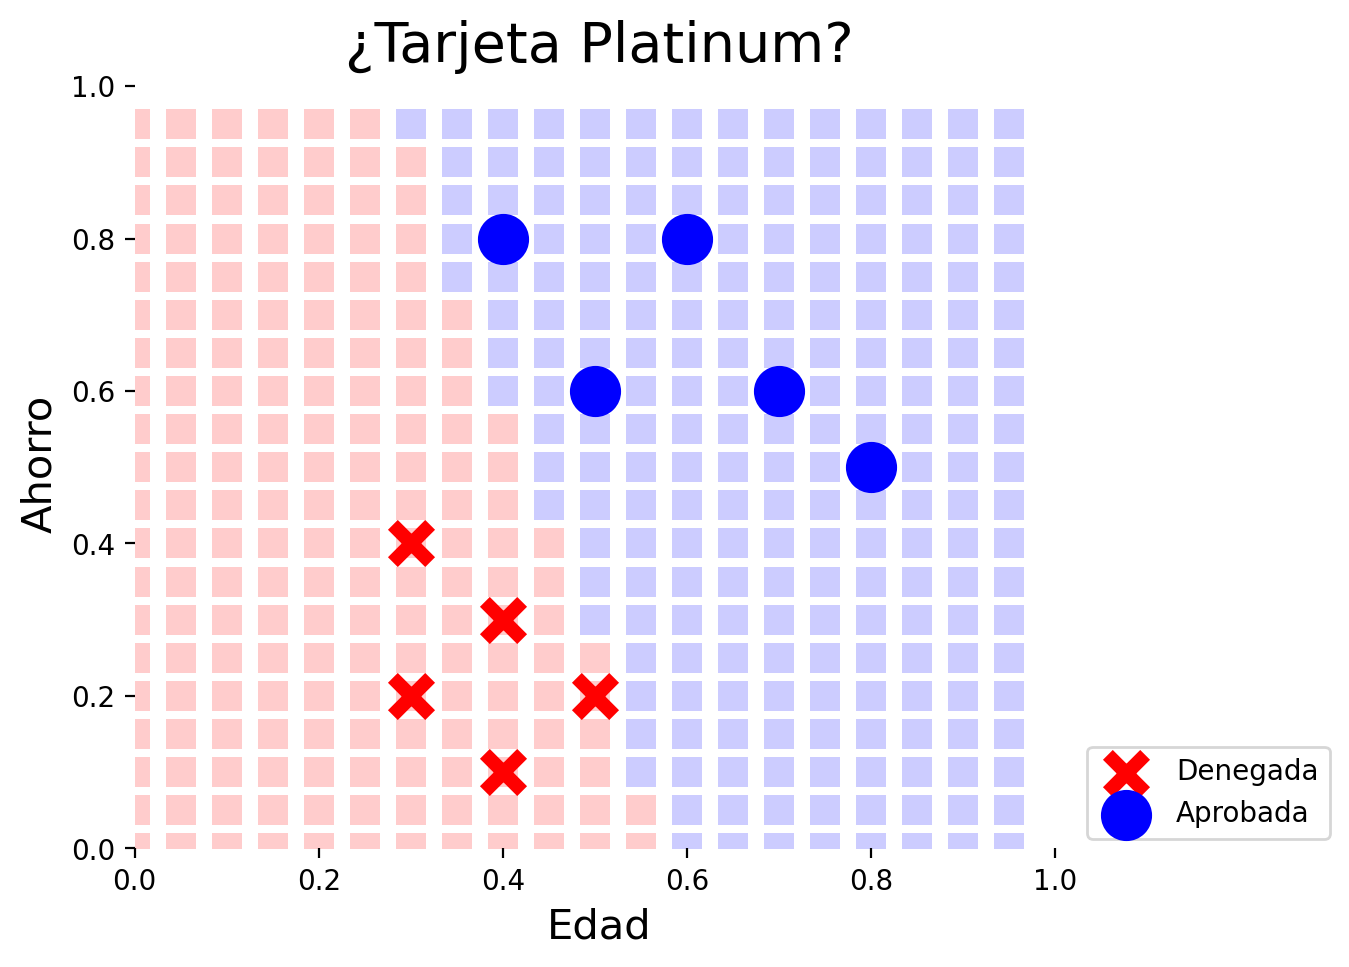

In [15]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

plt.scatter(
    personas[clases == 0].T[0],
    personas[clases == 0].T[1],
    marker="x",
    s=180,
    color="red",
    linewidths=5,
    label="Denegada"
)

plt.scatter(
    personas[clases == 1].T[0],
    personas[clases == 1].T[1],
    marker="o",
    s=180,
    color="blue",
    linewidths=5,
    label="Aprobada"
)

for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        color = activacion(pesos, [edad, ahorro], b)

        if color == 1:
            plt.scatter(
                edad,
                ahorro,
                marker="s",
                s=110,
                color="blue",
                alpha=0.2,
                linewidths=0
            )
        else:
            plt.scatter(
                edad,
                ahorro,
                marker="s",
                s=110,
                color="red",
                alpha=0.2,
                linewidths=0)
plt.xlabel("Edad", fontsize=15) 
plt.ylabel("Ahorro", fontsize=15)
plt.legend (bbox_to_anchor=(1.3, 0.15))
plt.box (False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()

# Perceptron con Scikit-learn

In [21]:
from sklearn.linear_model import Perceptron
Perceptron = Perceptron().fit(personas, clases)
Perceptron.predict([[0.2, 0.2], [8.8, 0.8]])

array([0, 1])